### CS/ECE/ISyE 524 &mdash; Introduction to Optimization &mdash; Spring 2026 ###

# Project title goes here #

#### Student 1 (email address), Student 2 (email address), Student 3 (email address)

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Implementation and Solution](#3.-Implementation)
1. [Discussion of Results](#4.-Results-discussion)
1. [Optional Subsection](#4.A.-Feel-free-to-add-subsections)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

The first few sentences should give a quick overview of the entire project. Then, elaborate with a description of the problem that will be solved, a brief history (with [citations](https://en.wikipedia.org/wiki/Citation)) of how the problem came about, why it's important/interesting, and any other interesting facts you'd like to talk about. You should address and explain where the problem data is coming from (research? the internet? synthetically generated?) Also give an outline of the rest of the report.

This section **should be accessible to a general audience** (don't assume your reader has taken the class!). Feel free to include images if you think it'll be helpful:

![fixit flowchart][flow]

For more help on using Markdown, see [this reference](https://github.com/adam-p/markdown-here/wiki/Markdown-Cheatsheet).

[flow]: https://s-media-cache-ak0.pinimg.com/736x/f5/75/c5/f575c53b93724808c6f0211890a54900.jpg

## 2. Mathematical model ##

A discussion of the modeling assumptions made in the problem (e.g. is it from physics? economics? something else?). Explain the decision variables, the constraints, and the objective function. Finally, show the optimization problem written in standard form. If converting the problem to standard form would create a difficult-to-read model, it is okay to leave it in its simplest original form. Equations should be formatted in $\\LaTeX$ within the IJulia notebook. For this section you may **assume the reader is familiar with the material covered in class**.

Here is an example of an equation:

$$\begin{bmatrix}
      1 & 2 \\
       3 & 4
    \end{bmatrix}
    \begin{bmatrix} x \\ y \end{bmatrix} =
    \begin{bmatrix} 5 \\ 6 \end{bmatrix}$$

And here is an example of an optimization problem in easy-to-read form:
$$\begin{aligned}
  \underset{x \in \mathbb{R^n}}{\text{maximize}}\qquad& f_0(x) \\
    \text{subject to:}\qquad& f_i(x) \le 0 && i=1,\dots,m\\
    & h_j(x) = 0 && j=1,\dots,r
    \end{aligned}$$


## 3. Implementation \& Solutions ##

Here, you should code up your model in Julia + JuMP and solve it. Your code should be clean, easy to read, well annotated and commented, and it should compile! You are not allowed to use other programming languages or DCP packages such as `convex.jl`. I suggest having multiple code blocks separated by text blocks that explain the various parts of your solution. You may want to solve several versions of your problem with different models/assumptions. Suppress any code output that you don't explain in the body of the report.

It's fine to call external packages such as `Gurobi`, but try to minimize the use of exotic libraries.

Starting Optimization Loop for Pareto Frontier...
Pareto Frontier generated successfully.


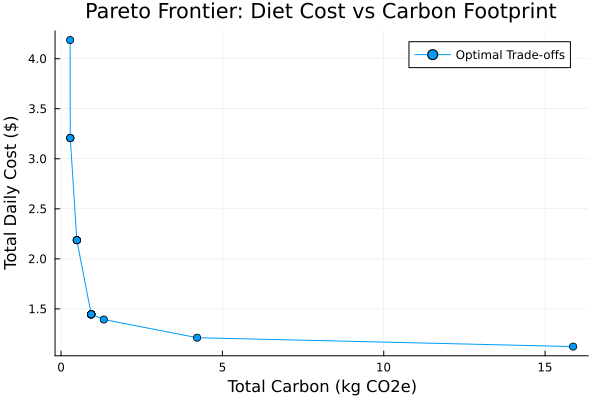

In [3]:
using JuMP, HiGHS, DataFrames, CSV, Plots

# 1. Data Loading and Preprocessing
# Load nutritional data and GHG emission data
food_df = CSV.read("food.csv", DataFrame)
ghg_df = CSV.read("ghg-per-kg-poore.csv", DataFrame)

# Define Mapping: Link Food categories to GHG entities
# Note: You can expand this dictionary based on your specific dataset
mapping = Dict(
    "Milk" => "Milk",
    "Beef" => "Beef (beef herd)",
    "Pork" => "Pig Meat",
    "Poultry" => "Poultry Meat",
    "Eggs" => "Eggs",
    "Cheese" => "Cheese",
    "Fish" => "Fish (farmed)",
    "Apples" => "Apples",
    "Bananas" => "Bananas",
    "Vegetables" => "Other Vegetables",
    "Nuts" => "Nuts"
)

# Convert GHG data to a lookup dictionary (kg CO2e per kg)
ghg_lookup = Dict(row.Entity => row."Greenhouse gas emissions per kilogram" for row in eachrow(ghg_df))

# Add a GHG value column to food_df (converted to per 100g)
food_df.GHG_per_100g = missings(Float64, nrow(food_df))
for i in 1:nrow(food_df)
    cat = food_df[i, :Category]
    if haskey(mapping, cat) && haskey(ghg_lookup, mapping[cat])
        food_df[i, :GHG_per_100g] = ghg_lookup[mapping[cat]] / 10.0
    end
end

# Placeholder for Prices: If food.csv lacks prices, we assign random costs for demonstration
# In a real project, replace this with actual price data
if !("Price" in names(food_df))
    food_df.Price = rand(0.5:0.1:5.0, nrow(food_df)) # Price per 100g
end

# Filter out rows with missing GHG data for optimization
optimized_pool = filter(row -> !ismissing(row.GHG_per_100g), food_df)
n = nrow(optimized_pool)

# 2. Pareto Frontier Generation
# We vary alpha from 0 (100% Carbon Focus) to 1 (100% Cost Focus)
alphas = 0.0:0.05:1.0
pareto_data = DataFrame(Alpha=Float64[], Total_Carbon=Float64[], Total_Cost=Float64[])

println("Starting Optimization Loop for Pareto Frontier...")

for α in alphas
    model = Model(HiGHS.Optimizer)
    set_silent(model)
    
    # Decision Variables: Grams of each food (in 100g units)
    @variable(model, x[1:n] >= 0)
    
    # Objective: Combined Weighted Function
    # Objective = α * Cost + (1 - α) * Carbon
    cost_expr = sum(x[i] * optimized_pool[i, :Price] for i in 1:n)
    carbon_expr = sum(x[i] * optimized_pool[i, :GHG_per_100g] for i in 1:n)
    @objective(model, Min, α * cost_expr + (1 - α) * carbon_expr)
    
    # Nutritional Constraints
    @constraint(model, sum(x[i] * optimized_pool[i, :"Data.Protein"] for i in 1:n) >= 50.0) # Min Protein
    @constraint(model, sum(x[i] * optimized_pool[i, :"Data.Fat.Total Lipid"] for i in 1:n) <= 65.0) # Max Fat
    @constraint(model, sum(x[i] * optimized_pool[i, :"Data.Major Minerals.Sodium"] for i in 1:n) <= 2300.0) # Max Sodium
    
    # Diversity: Max 500g of any single food
    for i in 1:n
        @constraint(model, x[i] <= 5.0)
    end
    
    optimize!(model)
    
    if termination_status(model) == MOI.OPTIMAL
        push!(pareto_data, (α, value(carbon_expr), value(cost_expr)))
    end
end

# 3. Visualization
p = plot(pareto_data.Total_Carbon, pareto_data.Total_Cost,
    title = "Pareto Frontier: Diet Cost vs Carbon Footprint",
    xlabel = "Total Carbon (kg CO2e)",
    ylabel = "Total Daily Cost (\$)",
    marker = :circle,
    grid = true,
    label = "Optimal Trade-offs")

display(p)
println("Pareto Frontier generated successfully.")

In [6]:
# --- Duality Analysis at a Middle Point ---
using Statistics

# 1. Pick a "Middle Point" Carbon Level 
# We can take the median carbon value from our previously generated Pareto data
if !isempty(pareto_data)
    target_carbon_cap = median(pareto_data.Total_Carbon)
    println("Performing Duality Analysis at Carbon Cap: ", round(target_carbon_cap, digits=2), " kg")

    # 2. Re-build the model for Shadow Price extraction
    dual_model = Model(HiGHS.Optimizer)
    set_silent(dual_model)

    @variable(dual_model, x[1:n] >= 0)

    # Constraint: Carbon limit (This is the one we will analyze)
    # We use a named constraint so we can refer to it later
    carbon_constraint = @constraint(dual_model, 
        sum(x[i] * optimized_pool[i, :GHG_per_100g] for i in 1:n) <= target_carbon_cap)

    # Objective: Minimize Cost ONLY
    @objective(dual_model, Min, sum(x[i] * optimized_pool[i, :Price] for i in 1:n))

    # Add all nutritional constraints (same as before)
    @constraint(dual_model, sum(x[i] * optimized_pool[i, :"Data.Protein"] for i in 1:n) >= 50.0)
    @constraint(dual_model, sum(x[i] * optimized_pool[i, :"Data.Fat.Total Lipid"] for i in 1:n) <= 65.0)
    # ... add other constraints ...

    optimize!(dual_model)

    if termination_status(dual_model) == MOI.OPTIMAL
        # 3. Extract the Shadow Price (Dual Value)
        # The dual value represents ΔCost / ΔCarbon_Cap
        carbon_shadow_price = dual(carbon_constraint)
        
        println("Analysis Results:")
        println("Optimized Daily Cost: \$", round(objective_value(dual_model), digits=2))
        println("Shadow Price of Carbon: ", round(abs(carbon_shadow_price), digits=4), " \$/kg CO2e")
        
        # Interpretation
        println("\nInterpretation:")
        println("At this dietary balance, reducing carbon emissions by 1kg ")
        println("would cost an additional \$", round(abs(carbon_shadow_price), digits=2), ".")
    end
end

Performing Duality Analysis at Carbon Cap: 0.94 kg
Analysis Results:
Optimized Daily Cost: $1.45
Shadow Price of Carbon: 0.1334 $/kg CO2e

Interpretation:
At this dietary balance, reducing carbon emissions by 1kg 
would cost an additional $0.13.


## 4. Discussion of Results ##

Here, you display and discuss the results. Show figures, tables, plots, images, trade-off curves, or whatever else you can think of to best illustrate your results. The discussion should explain what the results mean, and how to interpret them. You should also explain the limitations of your approach/model and how sensitive your results are to the assumptions you made.

 Use plots (see `Plots` examples from class), or you can display results in a table like this:

| Tables        | Are          | Cool  |
| ------------- |:-------------| -----:|
| col 3 is      |right-aligned |\$1600 |
|  colons       | align columns|  \$12 |
| zebra stripes |    are neat  |   \$1 |

### 4.A. Feel free to add subsections

#### 4.A.a. or subsubsections

## 5. Conclusion ##

Summarize your findings and your results, and talk about at least one possible future direction; something that might be interesting to pursue as a follow-up to your project.